## Setup

In [ ]:
!git clone --branch 4-pareto-test https://github.com/GoharKhachatryan/GenAI_project.git

Cloning into 'GenAI_project'...
remote: Enumerating objects: 267, done.
remote: Counting objects: 100% (267/267), done.
remote: Compressing objects: 100% (226/226), done.
remote: Total 267 (delta 158), reused 107 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (267/267), 1.47 MiB | 9.16 MiB/s, done.
Resolving deltas: 100% (158/158), done.


In [ ]:
%cd GenAI_project

/content/GenAI_project


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ln -s /content/drive/MyDrive/for_bostongene/data /content/GenAI_project/data
!ln -s /content/drive/MyDrive/for_bostongene/dataset.pt /content/GenAI_project/dataset.pt
!ln -s /content/drive/MyDrive/for_bostongene/pca_cache.npz /content/GenAI_project/pca_cache.npz
!ln -s /content/drive/MyDrive/for_bostongene/probe_weights.pt /content/GenAI_project/probe_weights.pt

## Info

This notebook performs the evaluation for the task 4.

## Imports

In [ ]:
import random
import time
import os

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from prepare_dataset import PairedCIFAR10

from pseudo_crossmodal import (
    extract_condition,
    load_pca,
)

from quality_probe import load_probe

from scripts.unet import UNet
from scripts.blocks import ScaleShiftResBlock
from scripts.model import ConditionalDenoiser
from scripts.diffusion import DDPM

from scripts.samplers import (
    ddpm_sample_respaced,
    ddim_sample,
)

## Reproducibility, Device and Configs

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [ ]:
CHECKPOINT_PATH = "/content/drive/MyDrive/for_bostongene/checkpoints/add_scale_shift/best_model.pt"

RESULTS_PATH = "/content/drive/MyDrive/for_bostongene/task4.pt"

## Test set & Results

In [ ]:
test_dataset = PairedCIFAR10("test")

eval_indices = list(
    range(len(test_dataset))
)

In [ ]:
index_generator = (
    torch.Generator()
    .manual_seed(SEED)
)

perm = torch.randperm(
    len(eval_indices),
    generator=index_generator,
).tolist()

eval_indices = [
    eval_indices[i]
    for i in perm
]

In [ ]:
eval_conditions = []
eval_labels = []

for idx in eval_indices:
    _, cond, label = test_dataset[idx]

    eval_conditions.append(cond)
    eval_labels.append(label)

eval_conditions = torch.stack(
    eval_conditions
)

eval_labels = torch.stack(
    eval_labels
).long()

print(eval_conditions.shape)
print(eval_labels.shape)

torch.Size([10000, 16])
torch.Size([10000])


In [ ]:
def save_results(results, path=RESULTS_PATH):
    torch.save(results, path)

In [ ]:
if os.path.exists(RESULTS_PATH):
    results = torch.load(
        RESULTS_PATH,
        map_location="cpu",
    )
    print(f"Loaded {len(results)} existing results.")
else:
    results = {}

## Model & Weights

In [ ]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
)

In [ ]:
cond_mean = checkpoint["cond_mean"]
cond_std = checkpoint["cond_std"]

eval_conditions_norm = (
    eval_conditions - cond_mean
) / (cond_std + 1e-8)

In [ ]:
unet = UNet(
    in_channels=3,
    out_channels=3,
    base_channels=64,
    emb_dim=256,
    block_cls=ScaleShiftResBlock,
)

model = ConditionalDenoiser(
    unet=unet,
    time_dim=256,
    cond_dim=16,
    emb_dim=256,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

ConditionalDenoiser(
  (unet): UNet(
    (init_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (enc1): ScaleShiftResBlock(
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (emb_proj): Linear(in_features=256, out_features=128, bias=True)
      (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (skip): Identity()
    )
    (down1): Downsample(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (enc2): ScaleShiftResBlock(
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (emb_proj): Linear(in_features=256, out_features=256, bias=True)
      (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1

## Sample fixed x_init

In [ ]:
noise_generator = (
    torch.Generator()
    .manual_seed(SEED)
)

x_init_all = torch.randn(
    len(eval_indices),
    3,
    32,
    32,
    generator=noise_generator,
)

print(x_init_all.shape)

torch.Size([10000, 3, 32, 32])


## Diffusion, PCA, Classifier & Cycle

In [ ]:
diffusion = DDPM(
    timesteps=1000,
    schedule="cosine",
    device=device,
)

pca_state = load_pca()

In [ ]:
probe = load_probe(
    device=str(device)
)

probe.eval()

Probe(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=2048, out_features=128, bias=True)
    (14): ReLU()
    (15): Linear(in_features=128, out_features=10, bi

In [ ]:
def compute_cycle_metrics(
    cond_true,
    cond_hat,
    cond_std,
):
    error = cond_true - cond_hat

    raw_l2 = torch.linalg.vector_norm(
        error,
        dim=1,
    )

    standardized_error = (
        error
        / (cond_std + 1e-8)
    )

    standardized_l2 = torch.linalg.vector_norm(
        standardized_error,
        dim=1,
    )

    feature_mae = (
        error.abs().mean(dim=0)
    )

    feature_mae_std = (
        standardized_error.abs().mean(dim=0)
    )

    return {
        "raw_l2": raw_l2,
        "standardized_l2": standardized_l2,
        "feature_mae": feature_mae,
        "feature_mae_std": feature_mae_std,
    }

## Experiment configs

In [ ]:
STEP_COUNTS = [
    500,
    100,
    50,
    20,
    10,
]

SAMPLERS = [
    "ddpm",
    "ddim",
]

BATCH_SIZE = 128
DDIM_ETA = 0.0

## Evaluating function (for both metrics at once)

In [ ]:
@torch.no_grad()
def evaluate_sampler(
    model,
    probe,
    sampler_name,
    num_steps,
    cond_original,
    cond_normalized,
    labels,
    x_init_all,
    cond_std,
    pca_state,
    diffusion,
    batch_size=128,
    eta=0.0,
):
    all_cond_hat = []

    correct = 0
    total = 0

    # Synchronize CUDA so runtime measurement is accurate
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.time()

    for start in range(
        0,
        len(cond_original),
        batch_size,
    ):
        end = min(
            start + batch_size,
            len(cond_original),
        )

        cond_batch = (
            cond_normalized[start:end]
            .to(device)
        )

        x_init_batch = (
            x_init_all[start:end]
            .to(device)
        )

        label_batch = (
            labels[start:end]
            .to(device)
        )

        # Generate
        if sampler_name == "ddpm":

            generated = ddpm_sample_respaced(
                model=model,
                ddpm=diffusion,
                cond=cond_batch,
                num_steps=num_steps,
                x_init=x_init_batch,
            )

        elif sampler_name == "ddim":

            generated = ddim_sample(
                model=model,
                ddpm=diffusion,
                cond=cond_batch,
                num_steps=num_steps,
                eta=eta,
                x_init=x_init_batch,
            )

        else:
            raise ValueError(
                f"Unknown sampler: {sampler_name}"
            )

        # Cycle consistency
        cond_hat = extract_condition(
            generated,
            pca_state,
        )

        all_cond_hat.append(
            cond_hat.cpu()
        )

        # External quality probe
        logits = probe(generated)

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.numel()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    runtime_sec = (
        time.time() - start_time
    )

    cond_hat = torch.cat(
        all_cond_hat,
        dim=0,
    )

    cycle_metrics = compute_cycle_metrics(
        cond_true=cond_original,
        cond_hat=cond_hat,
        cond_std=cond_std,
    )

    return {
        **cycle_metrics,
        "conditional_accuracy":
            correct / total,
        "runtime_sec":
            runtime_sec,
    }

## Evaluate the classifier

In [ ]:
@torch.no_grad()
def evaluate_probe_on_real_images(
    probe,
    dataset,
    indices,
    batch_size=256,
):
    correct = 0
    total = 0

    for start in range(
        0,
        len(indices),
        batch_size,
    ):
        batch_indices = indices[
            start:start + batch_size
        ]

        images = []
        labels = []

        for idx in batch_indices:
            image, _, label = dataset[idx]

            images.append(image)
            labels.append(label)

        images = (
            torch.stack(images)
            .to(device)
        )

        labels = (
            torch.stack(labels)
            .long()
            .to(device)
        )

        logits = probe(images)

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.numel()

    return correct / total

In [ ]:
probe_test_accuracy = (
    evaluate_probe_on_real_images(
        probe,
        test_dataset,
        eval_indices,
    )
)

print(
    "Probe accuracy on real test images:",
    probe_test_accuracy,
)

Probe accuracy on real test images: 0.7582


In [ ]:
print(
    f"Real-image probe baseline: "
    f"{probe_test_accuracy:.4f}"
)

Real-image probe baseline: 0.7582


## Assert before the long run

In [ ]:
assert eval_conditions.shape == (10000, 16)
assert eval_conditions_norm.shape == (10000, 16)
assert eval_labels.shape == (10000,)
assert x_init_all.shape == (10000, 3, 32, 32)

assert torch.isfinite(eval_conditions).all()
assert torch.isfinite(eval_conditions_norm).all()
assert torch.isfinite(x_init_all).all()

print("Task 4 evaluation setup validated.")

Task 4 evaluation setup validated.


## Evaluation loop

In [ ]:
for sampler_name in SAMPLERS:
    for num_steps in STEP_COUNTS:

        key = (
            sampler_name,
            num_steps,
        )

        # Since I am using Colab, the runtime may be interrupted
        # So skip the finished configurations
        if key in results:
            print(
                f"Skipping {key}: already computed."
            )
            continue

        print(
            f"\nEvaluating {sampler_name.upper()} "
            f"with {num_steps} steps..."
        )

        torch.manual_seed(SEED)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED)

        result = evaluate_sampler(
            model=model,
            probe=probe,
            sampler_name=sampler_name,
            num_steps=num_steps,
            cond_original=eval_conditions,
            cond_normalized=eval_conditions_norm,
            labels=eval_labels,
            x_init_all=x_init_all,
            cond_std=cond_std,
            pca_state=pca_state,
            diffusion=diffusion,
            batch_size=BATCH_SIZE,
            eta=DDIM_ETA,
        )

        results[key] = result

        save_results(
            results,
            path=RESULTS_PATH,
        )

        print(
            "  standardized cycle L2:",
            result["standardized_l2"]
            .mean()
            .item(),
        )

        print(
            "  conditional accuracy:",
            result["conditional_accuracy"],
        )

        print(
            "  runtime:",
            round(
                result["runtime_sec"],
                1,
            ),
            "sec",
        )

        print("  Results saved.")


Evaluating DDPM with 500 steps...
  standardized cycle L2: 0.24477533996105194
  conditional accuracy: 0.2948
  runtime: 2553.4 sec
  Results saved.

Evaluating DDPM with 100 steps...
  standardized cycle L2: 0.2457181215286255
  conditional accuracy: 0.2879
  runtime: 510.1 sec
  Results saved.

Evaluating DDPM with 50 steps...
  standardized cycle L2: 0.2512980103492737
  conditional accuracy: 0.289
  runtime: 254.6 sec
  Results saved.

Evaluating DDPM with 20 steps...
  standardized cycle L2: 0.2811725437641144
  conditional accuracy: 0.2961
  runtime: 101.7 sec
  Results saved.

Evaluating DDPM with 10 steps...
  standardized cycle L2: 0.3504510819911957
  conditional accuracy: 0.2946
  runtime: 51.0 sec
  Results saved.

Evaluating DDIM with 500 steps...
  standardized cycle L2: 0.38970932364463806
  conditional accuracy: 0.2727
  runtime: 2549.0 sec
  Results saved.

Evaluating DDIM with 100 steps...
  standardized cycle L2: 0.4007309079170227
  conditional accuracy: 0.2742
  r

## Results

In [ ]:
rows = []

for (sampler, steps), result in results.items():

    rows.append({
        "sampler": sampler.upper(),
        "steps": steps,

        "cycle_l2":
            result["raw_l2"].mean().item(),

        "standardized_cycle_l2":
            result["standardized_l2"].mean().item(),

        "conditional_accuracy":
            result["conditional_accuracy"],

        "runtime_sec":
            result["runtime_sec"],
    })

summary_df = pd.DataFrame(rows)

summary_df = summary_df.sort_values(
    ["sampler", "steps"],
    ascending=[True, False],
)

summary_df

,sampler,steps,cycle_l2,standardized_cycle_l2,conditional_accuracy,runtime_sec
5,DDIM,500,1.248297,0.389709,0.2727,2548.982521
6,DDIM,100,1.278770,0.400731,0.2742,512.060072
7,DDIM,50,1.306542,0.412925,0.2742,256.533555
8,DDIM,20,1.473839,0.474978,0.2746,102.659824
9,DDIM,10,1.822552,0.603225,0.2682,51.380838
0,DDPM,500,0.751438,0.244775,0.2948,2553.426088
1,DDPM,100,0.731805,0.245718,0.2879,510.078008
2,DDPM,50,0.718171,0.251298,0.2890,254.639331
3,DDPM,20,0.694866,0.281173,0.2961,101.726188
4,DDPM,10,0.683601,0.350451,0.2946,51.043321


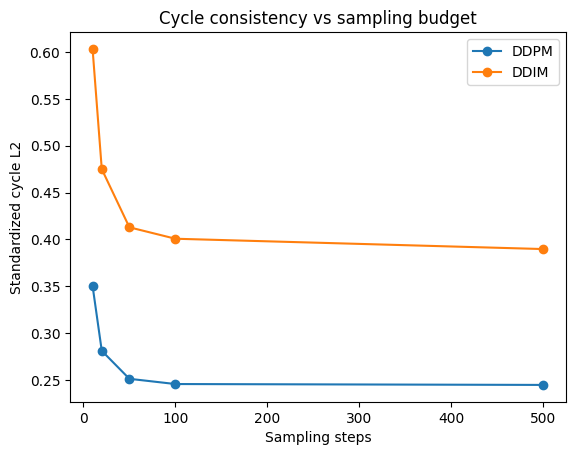

In [ ]:
# A plot per metric
for sampler in ["DDPM", "DDIM"]:
    df = summary_df[
        summary_df["sampler"] == sampler
    ].sort_values("steps")

    plt.plot(
        df["steps"],
        df["standardized_cycle_l2"],
        marker="o",
        label=sampler,
    )

plt.xlabel("Sampling steps")
plt.ylabel("Standardized cycle L2")
plt.title("Cycle consistency vs sampling budget")
plt.legend()
plt.show()

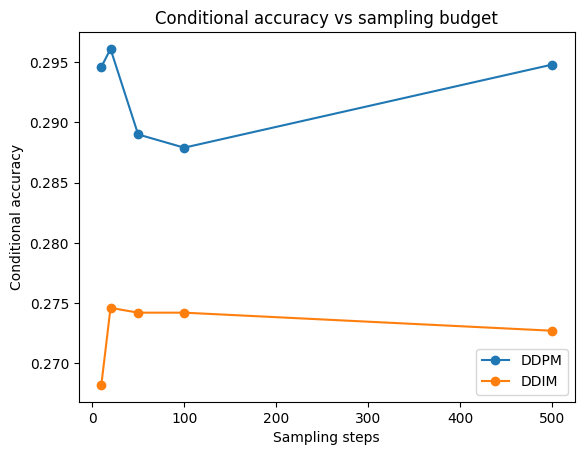

In [ ]:
for sampler in ["DDPM", "DDIM"]:
    df = summary_df[
        summary_df["sampler"] == sampler
    ].sort_values("steps")

    plt.plot(
        df["steps"],
        df["conditional_accuracy"],
        marker="o",
        label=sampler,
    )

plt.xlabel("Sampling steps")
plt.ylabel("Conditional accuracy")
plt.title("Conditional accuracy vs sampling budget")
plt.legend()
plt.show()

## Pareto plots

In [ ]:
plt.figure(figsize=(7, 5))

for sampler in ["DDPM", "DDIM"]:
    df = (
        summary_df[
            summary_df["sampler"] == sampler
        ]
        .sort_values("steps")
    )

    plt.plot(
        df["steps"],
        df["standardized_cycle_l2"],
        marker="o",
        label=sampler,
    )

plt.xlabel("Sampling steps")
plt.ylabel("Standardized cycle L2 ↓")
plt.title(
    "Quality–compute trade-off: "
    "cycle consistency"
)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))

for sampler in ["DDPM", "DDIM"]:
    df = (
        summary_df[
            summary_df["sampler"] == sampler
        ]
        .sort_values("steps")
    )

    plt.plot(
        df["steps"],
        df["conditional_accuracy"],
        marker="o",
        label=sampler,
    )

plt.axhline(
    probe_test_accuracy,
    linestyle="--",
    label="Probe on real test images",
)

plt.xlabel("Sampling steps")
plt.ylabel("Conditional accuracy ↑")

plt.title(
    "Quality–compute trade-off: "
    "conditional accuracy"
)

plt.legend()
plt.tight_layout()
plt.show()

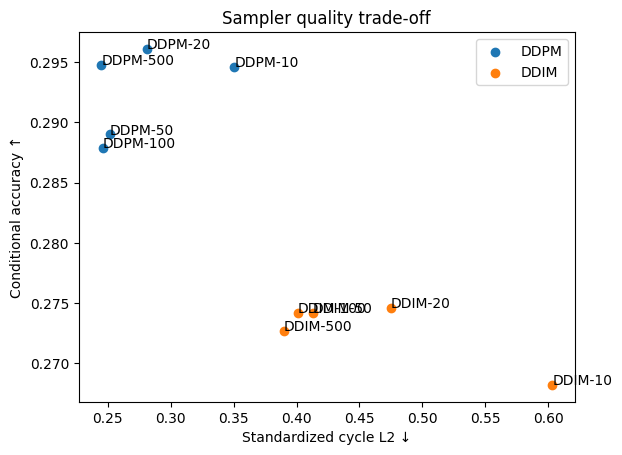

In [ ]:
for sampler in ["DDPM", "DDIM"]:
    df = summary_df[
        summary_df["sampler"] == sampler
    ]

    plt.scatter(
        df["standardized_cycle_l2"],
        df["conditional_accuracy"],
        label=sampler,
    )

    for _, row in df.iterrows():
        plt.annotate(
            f'{sampler}-{int(row["steps"])}',
            (
                row["standardized_cycle_l2"],
                row["conditional_accuracy"],
            ),
        )

plt.xlabel(
    "Standardized cycle L2 ↓"
)

plt.ylabel(
    "Conditional accuracy ↑"
)

plt.title(
    "Sampler quality trade-off"
)

plt.legend()
plt.show()